In [1]:
# combine single time points (plate reader) to growth curve analyses

In [2]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.5.2
✔ readr   2.1.5     ✔ tibble  3.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
getwd()

[1] "/home/strawperry/Documents/Masters/growth_curves"

In [10]:
# Load plates
pattern <- "^100226_.*h.tsv$"   # files starting with DATE and ending in h.tsv

# Check if files were assigned correctly 
files <- list.files(pattern = pattern, full.names = TRUE)
files

# read each file into a df
plate_dfs <- files %>%
  map(~ read_tsv(.x, col_names = FALSE, skip = 1, show_col_types = FALSE)) %>% # load each tsv file
  map(~ setNames(.x, c("Row", as.character(1:12)))) # name columns

plate_dfs

[1] "./100226_0h.tsv"  "./100226_24h.tsv" "./100226_2h.tsv"  "./100226_30h.tsv"
[5] "./100226_48h.tsv" "./100226_4h.tsv"  "./100226_6h.tsv"  "./100226_8h.tsv"

Row,1,2,3,4,5,6,7,8,9,10,11,12
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A,"0,066","0,062","0,065","0,062","0,063","0,064","0,064","0,063","0,063","0,061","0,067","0,061"
B,"0,063","0,067","0,065","0,062","0,061","0,065","0,062","0,063","0,062","0,062","0,064","0,061"
C,"0,064","0,068","0,064","0,061","0,06","0,064","0,061","0,063","0,063","0,063","0,064","0,062"
D,"0,05","0,049","0,05","0,05","0,048","0,05","0,049","0,051","0,05","0,05","0,051","0,051"
E,"0,065","0,065","0,066","0,064","0,061","0,062","0,061","0,058","0,062","0,063","0,059","0,059"
F,"0,066","0,067","0,065","0,064","0,06","0,061","0,062","0,059","0,061","0,063","0,068","0,058"
G,"0,066","0,064","0,065","0,063","0,061","0,062","0,063","0,06","0,062","0,06","0,059","0,059"
H,"0,043","0,043","0,041","0,042","0,049","0,049","0,052","0,049","0,048","0,05","0,05","0,049"
Row,1,2,3,4,5,6,7,8,9,10,11,12


In [11]:
process_plate_file <- function(file) {

  ## Extract incubation time (hours) from filename
  ## Example: 100226_24h.tsv -> 24
  time_hr <- sub(".*_(\\d+)h.*", "\\1", basename(file))
  time_hr <- as.numeric(time_hr)

  ## Import plate (already in Row + 1:12 format)
  raw <- read_tsv(
    file,
    col_names = FALSE,
    skip = 1,
    show_col_types = FALSE
  )

  ## Assign column names
  colnames(raw) <- c("Row", as.character(1:12))

  ## Convert to long format
  long <- raw %>%
    pivot_longer(
      cols = -Row,
      names_to = "Col",
      values_to = "OD600"
    ) %>%
    mutate(
      Well  = paste0(Row, Col),
      OD600 = as.numeric(gsub(",", ".", OD600)),
      Time_hr = time_hr
    ) %>%
    select(Time_hr, Well, Row, Col, OD600)

  return(long)
}

In [12]:
growth_data <- files %>%
  purrr::map_dfr(process_plate_file)
growth_data

Time_hr,Well,Row,Col,OD600
<dbl>,<chr>,<chr>,<chr>,<dbl>
0,A1,A,1,0.066
0,A2,A,2,0.062
0,A3,A,3,0.065
0,A4,A,4,0.062
0,A5,A,5,0.063
0,A6,A,6,0.064
0,A7,A,7,0.064
0,A8,A,8,0.063
0,A9,A,9,0.063


In [14]:
tail(growth_data)

Time_hr,Well,Row,Col,OD600
<dbl>,<chr>,<chr>,<chr>,<dbl>
8,H7,H,7,0.050
8,H8,H,8,0.050
8,H9,H,9,0.048
8,H10,H,10,0.050
8,H11,H,11,0.049
8,H12,H,12,0.051


In [16]:
# annotation function for long-format data
annotate_growth_data <- function(df) {

  df %>%
    mutate(

      ## Carbon source by column
      Carbon = case_when(
        Col %in% c("1", "2", "3")   ~ "M9_GLU",
        Col %in% c("4", "5", "6")   ~ "M9_SIA",
        Col %in% c("7", "8", "9")   ~ "M9_LAC",
        Col %in% c("10","11","12")  ~ "M9",
        TRUE                  ~ NA_character_
      ),

      ## Strain by row
      Strain = case_when(
        Row %in% c("A", "B", "C") ~ "29213",
        Row %in% c("E", "F", "G") ~ "43300",
        Row == "H"                ~ "Blank",
        TRUE                      ~ NA_character_
      )
    )
}

In [18]:
growth_data_annotated <- annotate_growth_data(growth_data)
head(growth_data_annotated)
tail(growth_data_annotated)

Time_hr,Well,Row,Col,OD600,Carbon,Strain
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
0,A1,A,1,0.066,M9_GLU,29213
0,A2,A,2,0.062,M9_GLU,29213
0,A3,A,3,0.065,M9_GLU,29213
0,A4,A,4,0.062,M9_SIA,29213
0,A5,A,5,0.063,M9_SIA,29213
0,A6,A,6,0.064,M9_SIA,29213


Time_hr,Well,Row,Col,OD600,Carbon,Strain
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
8,H7,H,7,0.050,M9_LAC,Blank
8,H8,H,8,0.050,M9_LAC,Blank
8,H9,H,9,0.048,M9_LAC,Blank
8,H10,H,10,0.050,M9,Blank
8,H11,H,11,0.049,M9,Blank
8,H12,H,12,0.051,M9,Blank


In [21]:
# Remove unwanted wells
od_tp_long <- growth_data_annotated %>%
  filter(
    !Row %in% c("D"), 
    !Col %in% c(3, 6, 9, 10, 11, 12)) 
tail(od_tp_long)

Time_hr,Well,Row,Col,OD600,Carbon,Strain
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
8,H1,H,1,0.041,M9_GLU,Blank
8,H2,H,2,0.043,M9_GLU,Blank
8,H4,H,4,0.042,M9_SIA,Blank
8,H5,H,5,0.049,M9_SIA,Blank
8,H7,H,7,0.050,M9_LAC,Blank
8,H8,H,8,0.050,M9_LAC,Blank


In [22]:
# # COrrect OD to cuvette
# od_tp_long2_cuvette <- od_tp_long2 %>%
#   mutate(OD = OD * 1.8)
# head(od_tp_long2_cuvette)

# write_tsv(od_tp_long2_cuvette, "saureus_m9-anox_210126-cuvette.tsv")

`geom_smooth()` using formula = 'y ~ x'


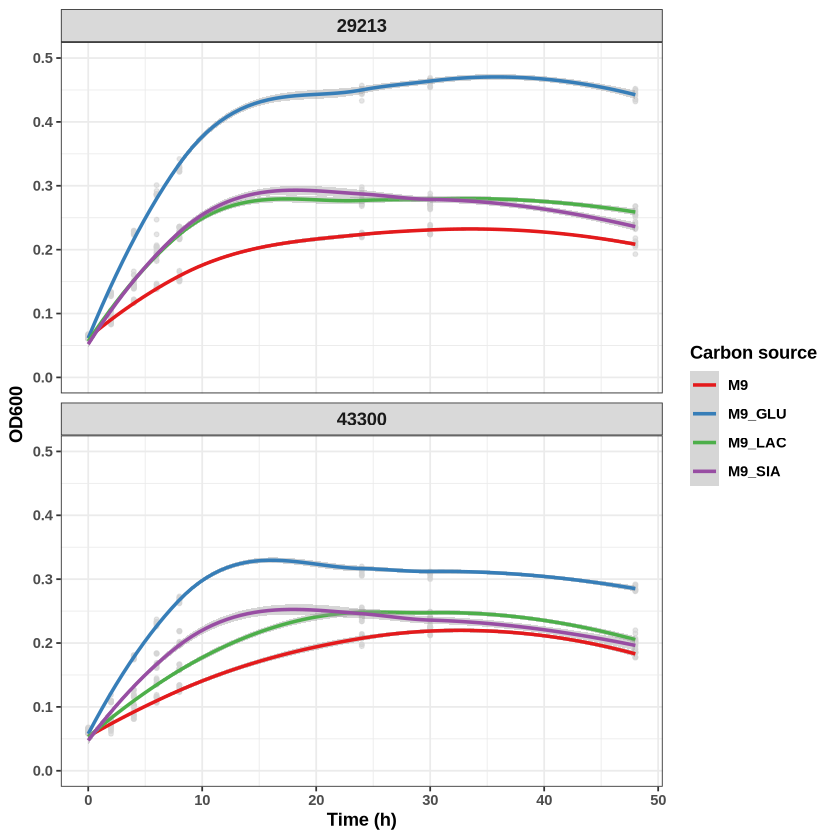

In [27]:
a <- ggplot(
  growth_data_annotated %>%
    filter(
      !is.na(Carbon),
      Strain != "Blank"
    ),
  aes(x = Time_hr, y = OD600)
) +
  ## Individual wells (raw trajectories)
  geom_point(
    aes(group = Well),
    color = "lightgray",
    size  = 1,
    alpha = 0.6
  ) +

  ## Smoothed growth curves by carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span   = 0.8,
    se     = TRUE,
    linewidth = 1
  ) +

  ## One panel per strain
  facet_wrap(
    ~ Strain,
    ncol = 1,
    scales = "free_y"
  ) +

  scale_color_brewer(palette = "Set1") +
  scale_y_continuous(limits = c(0, 0.5)) +

  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon source"
  ) +

  theme_bw() +
  theme(
    strip.text   = element_text(face = "bold", size = 11),
    axis.title   = element_text(face = "bold"),
    axis.text    = element_text(face = "bold"),
    legend.title = element_text(face = "bold"),
    legend.text  = element_text(face = "bold"),
    plot.title   = element_text(face = "bold", hjust = 0.5)
  )
a

In [28]:
ggsave(
  filename = "growth_curves_M9_100226.png",
  plot     = a
)

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'
